# Performance impact of MTP in Gemma 4
Gemma 4 models can be run with MTP (Multi-Token Prediction). This is a specialized implementation of Speculative Decoding where a smaller model (called the "draft" model) generates several tokens ahead of the main model. The main model verifies the drafted tokens in a single forward pass and smaller models generate tokens faster than big ones.

This has the potential of accelerating inference during the decoding phase. It doesn't have an impact on the Time to First Token. When we run MTP (Speculative Decoding) it is important to find the optimal amount of tokens we want the draft model to predict. If we draft too few, then we are leaving performance on the table. If we draft too many, then the main model will discard a big part of the effort of the small model which translates into wasted GPU compute. The optimal number depends on the task. The amount of tokens the main model accepts is called the "acceptance rate" (= accepted tokens / proposed tokens).


### Setup and Testing Procedure
In this exercise I am going to test Gemma4 31b base model vs MTP.

We will run Nvidia's `aiperf` benchmarking tool using the same test configuration for the base model and for several MTP configuration (1, 2, 4 and 6 speculative tokens). From the aiperf output we will focus on:
- the average **TTFT** (Time to First Token)
- the **Tokens per second** (Throughput)

We will also calculate the **Acceptance Rate** by querying the vLLM metrics. 

My Environment consists of a VM running Ubuntu 24.04 and a Blackwell RTX Pro 6000. This GPU has 96GB. At BF16 the base model is consuming approx 60GB according to the "nvidia-smi" inside the container itself. According to the documentation, the drafter model is only 78 million parameters, so it has very little VRAM overhead.

The model runs on Docker with vLLM inference server. This is how I run the **base model**

```bash
docker run --gpus '"device=0"' \
  -v ~/.cache/huggingface:/root/.cache/huggingface \
  -p 8080:8000 \
  --ipc=host \
  vllm/vllm-openai:gemma4-0505-cu130 \
  --model google/gemma-4-31b-it \
  --enable-auto-tool-choice \
  --tool-call-parser gemma4 \
  --reasoning-parser gemma4 \
  --gpu-memory-utilization 0.92 \
  --max-model-len 65536 \
  --enable-prefix-caching \
  --dtype bfloat16 \
```

To enable MTP we only need to add an extra parameter `--speculative-config`. The last key in that curly brackets `"num_speculative_tokens":1` is how determine how many tokens the 'draft' model needs to generate (1, 2, 4 and 6)

```bash
  --speculative-config '{"method":"mtp","model":"google/gemma-4-31b-it-assistant","num_speculative_tokens":1}'
  ```


This the the `aiperf` test we will run for all 5 scenarios. I am running the test once to warm up the model and then a second time to gather the results.

```bash
aiperf profile  \
  --model "google/gemma-4-31b-it"  \
  --streaming \
  --endpoint-type chat \
  --tokenizer google/gemma-4-31b-it \
  --url http://localhost:8000/v1 \
  --concurrency 4 \
  --isl 100 \
  --osl 500 \
  --request-count 50 
```

Finally I am querying vLLM to get the amount of draft and accepted tokens to calculate the acceptance rate:

```bash
curl http://localhost:8000/metrics | grep vllm:spec_decode_num_draft_tokens_total
curl http://localhost:8000/metrics | grep vllm:spec_decode_num_accepted_tokens_total
```

The formula is:

$\text{Acceptance Rate} = \frac{\text{Accepted Tokens}}{\text{Draft Tokens}}$


### Base Model
These are the results for the base model.
- TTFT = 137 ms
- TPS  = 106 Token/s

<div style="font-family: 'Consolas', 'Courier New', monospace; font-size: 12px; white-space: pre; overflow-x: auto; line-height: 1.2;">
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃                                        Metric ┃       avg ┃      min ┃       max ┃       p99 ┃       p90 ┃       p50 ┃      std ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│                      Time to First Token (ms) │    137.29 │    78.99 │    169.23 │    169.22 │    140.39 │    135.61 │    12.43 │
│                     Time to Second Token (ms) │     45.76 │    42.01 │     90.14 │     70.66 │     46.12 │     44.84 │     6.44 │
│               Time to First Output Token (ms) │    137.29 │    78.99 │    169.23 │    169.22 │    140.39 │    135.61 │    12.43 │
│                          Request Latency (ms) │ 19,961.86 │ 5,823.95 │ 22,669.17 │ 22,668.08 │ 22,660.24 │ 21,370.58 │ 3,510.03 │
│                      Inter Token Latency (ms) │     45.06 │    44.50 │     45.17 │     45.16 │     45.14 │     45.09 │     0.12 │
│              Output Token Throughput Per User │     22.19 │    22.14 │     22.47 │     22.44 │     22.23 │     22.18 │     0.06 │
│                             (tokens/sec/user) │           │          │           │           │           │           │          │
│ E2E Output Token Throughput (tokens/sec/user) │     22.08 │    21.98 │     22.36 │     22.34 │     22.10 │     22.07 │     0.06 │
│               Output Sequence Length (tokens) │    440.88 │   128.00 │    500.00 │    500.00 │    500.00 │    472.00 │    77.68 │
│                Input Sequence Length (tokens) │    100.00 │   100.00 │    100.00 │    100.00 │    100.00 │    100.00 │     0.00 │
│          Output Token Throughput (tokens/sec) │    106.50 │      N/A │       N/A │       N/A │       N/A │       N/A │      N/A │
│             Request Throughput (requests/sec) │      0.24 │      N/A │       N/A │       N/A │       N/A │       N/A │      N/A │
│                      Request Count (requests) │     50.00 │      N/A │       N/A │       N/A │       N/A │       N/A │      N/A │
└───────────────────────────────────────────────┴───────────┴──────────┴───────────┴───────────┴───────────┴───────────┴──────────┘
</div>
Let's see how these two numbers evolve as we ramp up MTP


### MTP with 1 speculative token
This is the first test with MTP on. MTP is drafting a single token
- TTFT = 144ms
- TPS  = 174 token/s
<div style="font-family: 'Consolas', 'Courier New', monospace; font-size: 12px; white-space: pre; overflow-x: auto; line-height: 1.2;">
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃                                        Metric ┃       avg ┃      min ┃       max ┃       p99 ┃       p90 ┃       p50 ┃      std ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│                      Time to First Token (ms) │    144.59 │    88.15 │    164.65 │    164.54 │    150.79 │    145.71 │    12.49 │
│                     Time to Second Token (ms) │     48.63 │    45.00 │     76.51 │     76.37 │     48.07 │     47.67 │     5.78 │
│               Time to First Output Token (ms) │    144.59 │    88.15 │    164.65 │    164.54 │    150.79 │    145.71 │    12.49 │
│                          Request Latency (ms) │ 11,923.20 │ 4,782.14 │ 14,198.96 │ 14,128.65 │ 13,847.14 │ 12,842.95 │ 2,489.99 │
│                      Inter Token Latency (ms) │     27.15 │    25.19 │     28.92 │     28.56 │     28.17 │     27.13 │     0.64 │
│              Output Token Throughput Per User │     36.85 │    34.58 │     39.69 │     39.03 │     37.81 │     36.87 │     0.86 │
│                             (tokens/sec/user) │           │          │           │           │           │           │          │
│ E2E Output Token Throughput (tokens/sec/user) │     36.46 │    34.26 │     38.73 │     38.31 │     37.42 │     36.47 │     0.84 │
│               Output Sequence Length (tokens) │    434.64 │   169.00 │    500.00 │    500.00 │    500.00 │    470.50 │    90.79 │
│                Input Sequence Length (tokens) │    100.00 │   100.00 │    100.00 │    100.00 │    100.00 │    100.00 │     0.00 │
│          Output Token Throughput (tokens/sec) │    174.44 │      N/A │       N/A │       N/A │       N/A │       N/A │      N/A │
│             Request Throughput (requests/sec) │      0.40 │      N/A │       N/A │       N/A │       N/A │       N/A │      N/A │
│                      Request Count (requests) │     50.00 │      N/A │       N/A │       N/A │       N/A │       N/A │      N/A │
└───────────────────────────────────────────────┴───────────┴──────────┴───────────┴───────────┴───────────┴───────────┴──────────┘
</div>

Also, querying the vLLM metrics as described above reveals:
- Draft tokens = 17523
- Accepted tokens = 13321
- Acceptance rate = 76%

### MTP with 2 speculative tokens
Results:
- TTFT = 155ms
- TPS  = 217 token/s
<div style="font-family: 'Consolas', 'Courier New', monospace; font-size: 12px; white-space: pre; overflow-x: auto; line-height: 1.2;">
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃                                        Metric ┃      avg ┃      min ┃       max ┃       p99 ┃       p90 ┃      p50 ┃      std ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│                      Time to First Token (ms) │   155.39 │    83.48 │    180.91 │    180.89 │    156.96 │   154.93 │    12.46 │
│                     Time to Second Token (ms) │    50.13 │    47.27 │     97.44 │     74.29 │     49.99 │    49.26 │     6.80 │
│               Time to First Output Token (ms) │   155.39 │    83.48 │    180.91 │    180.89 │    156.96 │   154.93 │    12.46 │
│                          Request Latency (ms) │ 8,805.35 │ 1,797.89 │ 12,014.32 │ 11,876.60 │ 10,975.12 │ 9,346.02 │ 2,331.87 │
│                      Inter Token Latency (ms) │    21.41 │    19.13 │     24.69 │     24.21 │     23.01 │    21.27 │     1.19 │
│              Output Token Throughput Per User │    46.84 │    40.50 │     52.27 │     52.13 │     50.25 │    47.02 │     2.58 │
│                             (tokens/sec/user) │          │          │           │           │           │          │          │
│ E2E Output Token Throughput (tokens/sec/user) │    46.01 │    38.79 │     51.13 │     50.82 │     48.68 │    46.39 │     2.41 │
│               Output Sequence Length (tokens) │   403.84 │    86.00 │    500.00 │    500.00 │    500.00 │   425.50 │   103.11 │
│                Input Sequence Length (tokens) │   100.00 │   100.00 │    100.00 │    100.00 │    100.00 │   100.00 │     0.00 │
│          Output Token Throughput (tokens/sec) │   217.27 │      N/A │       N/A │       N/A │       N/A │      N/A │      N/A │
│             Request Throughput (requests/sec) │     0.54 │      N/A │       N/A │       N/A │       N/A │      N/A │      N/A │
│                      Request Count (requests) │    50.00 │      N/A │       N/A │       N/A │       N/A │      N/A │      N/A │
└───────────────────────────────────────────────┴──────────┴──────────┴───────────┴───────────┴───────────┴──────────┴──────────┘
</div>

Also:
- Accepted Tokens = 30589
- Drafted Tokens = 46584
- Acceptance rate = 65%

### MTP with 4 speculative tokens
- TTFT = 161ms
- TPS  = 263 token/s
<div style="font-family: 'Consolas', 'Courier New', monospace; font-size: 12px; white-space: pre; overflow-x: auto; line-height: 1.2;">
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃                                        Metric ┃      avg ┃      min ┃       max ┃      p99 ┃      p90 ┃      p50 ┃      std ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│                      Time to First Token (ms) │   161.35 │   119.35 │    217.78 │   217.65 │   164.01 │   160.72 │    15.77 │
│                     Time to Second Token (ms) │    51.74 │    49.14 │     60.07 │    60.07 │    52.20 │    51.26 │     2.28 │
│               Time to First Output Token (ms) │   161.35 │   119.35 │    217.78 │   217.65 │   164.01 │   160.72 │    15.77 │
│                          Request Latency (ms) │ 8,020.57 │ 2,101.01 │ 10,105.55 │ 9,868.40 │ 9,259.51 │ 8,386.15 │ 1,392.67 │
│                      Inter Token Latency (ms) │    17.94 │    15.32 │     20.08 │    20.01 │    19.05 │    17.90 │     0.99 │
│              Output Token Throughput Per User │    55.90 │    49.79 │     65.27 │    64.10 │    59.70 │    55.88 │     3.14 │
│                             (tokens/sec/user) │          │          │           │          │          │          │          │
│ E2E Output Token Throughput (tokens/sec/user) │    54.84 │    48.81 │     63.88 │    62.84 │    58.57 │    54.85 │     3.08 │
│               Output Sequence Length (tokens) │   439.30 │   105.00 │    500.00 │   500.00 │   500.00 │   453.00 │    73.86 │
│                Input Sequence Length (tokens) │   100.00 │   100.00 │    100.00 │   100.00 │   100.00 │   100.00 │     0.00 │
│          Output Token Throughput (tokens/sec) │   263.01 │      N/A │       N/A │      N/A │      N/A │      N/A │      N/A │
│             Request Throughput (requests/sec) │     0.60 │      N/A │       N/A │      N/A │      N/A │      N/A │      N/A │
│                      Request Count (requests) │    50.00 │      N/A │       N/A │      N/A │      N/A │      N/A │      N/A │
└───────────────────────────────────────────────┴──────────┴──────────┴───────────┴──────────┴──────────┴──────────┴──────────┘
</div>

From vLLM metrics:
- Accepted Tokens = 17501
- Drafter Tokens = 36800
- Acceptance rate = 47%

### MTP with 6 speculative tokens
- TTFT = 232ms
- TPS  = 271 token/s
<div style="font-family: 'Consolas', 'Courier New', monospace; font-size: 12px; white-space: pre; overflow-x: auto; line-height: 1.2;">
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃                                        Metric ┃      avg ┃      min ┃      max ┃      p99 ┃      p90 ┃      p50 ┃      std ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│                      Time to First Token (ms) │   232.10 │   165.09 │   796.65 │   796.60 │   278.16 │   167.56 │   183.24 │
│                     Time to Second Token (ms) │    53.78 │    50.79 │    85.81 │    73.59 │    53.49 │    53.01 │     4.89 │
│               Time to First Output Token (ms) │   232.10 │   165.09 │   796.65 │   796.60 │   278.16 │   167.56 │   183.24 │
│                          Request Latency (ms) │ 7,961.32 │ 4,888.25 │ 9,739.58 │ 9,719.96 │ 9,431.32 │ 8,121.53 │ 1,146.82 │
│                      Inter Token Latency (ms) │    17.22 │    14.57 │    20.01 │    19.98 │    19.19 │    17.08 │     1.44 │
│              Output Token Throughput Per User │    58.48 │    49.98 │    68.61 │    68.17 │    65.53 │    58.54 │     4.92 │
│                             (tokens/sec/user) │          │          │          │          │          │          │          │
│ E2E Output Token Throughput (tokens/sec/user) │    56.85 │    42.14 │    67.20 │    66.78 │    63.60 │    56.94 │     5.10 │
│               Output Sequence Length (tokens) │   450.64 │   206.00 │   500.00 │   500.00 │   500.00 │   473.50 │    60.52 │
│                Input Sequence Length (tokens) │   100.00 │   100.00 │   100.00 │   100.00 │   100.00 │   100.00 │     0.00 │
│          Output Token Throughput (tokens/sec) │   271.97 │      N/A │      N/A │      N/A │      N/A │      N/A │      N/A │
│             Request Throughput (requests/sec) │     0.60 │      N/A │      N/A │      N/A │      N/A │      N/A │      N/A │
│                      Request Count (requests) │    50.00 │      N/A │      N/A │      N/A │      N/A │      N/A │      N/A │
└───────────────────────────────────────────────┴──────────┴──────────┴──────────┴──────────┴──────────┴──────────┴──────────┘
</div>

From vLLM metrics:
- Accepted Tokens = 18251
- Drafter Tokens = 50700
- Acceptance Rate = 35%

## Analysis 
Let's create a Pandas dataframe and graph the results

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = {
    'Model': ['Base', 'MTP1', 'MTP2', 'MTP4', 'MTP6'],
    'TTFT_ms': [137, 144, 155, 161, 232],
    'TPS': [106, 174, 217, 263, 271],
    'Acceptance_Rate': [np.nan, 76, 65, 47, 35]
}
df = pd.DataFrame(data)
df

,Model,TTFT_ms,TPS,Acceptance_Rate
0,Base,137,106,NaN
1,MTP1,144,174,76.0
2,MTP2,155,217,65.0
3,MTP4,161,263,47.0
4,MTP6,232,271,35.0


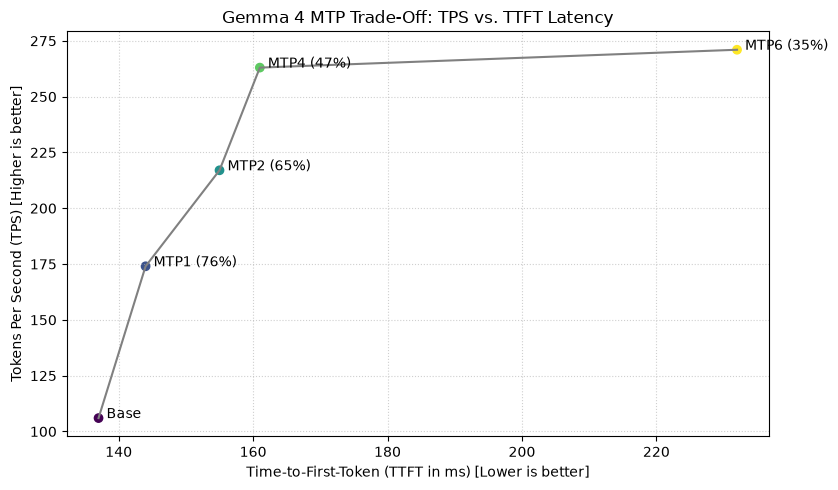

In [16]:
fig, ax = plt.subplots(figsize=(8.5, 5))

ax.plot(df['TTFT_ms'], df['TPS'], color='gray')
sc = ax.scatter(df['TTFT_ms'], df['TPS'], c=range(len(df)))

for idx, row in df.iterrows():
    acc_text = f" ({row['Acceptance_Rate']:.0f}%)" if pd.notnull(row['Acceptance_Rate']) else ""
    ax.annotate(f"  {row['Model']}{acc_text}", 
                (row['TTFT_ms'], row['TPS']))

ax.set_xlabel('Time-to-First-Token (TTFT in ms) [Lower is better]')
ax.set_ylabel('Tokens Per Second (TPS) [Higher is better]')
ax.set_title('Gemma 4 MTP Trade-Off: TPS vs. TTFT Latency')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

The graph shows that MTP is allowing us to ramp up throughput (Tokens per Second) by nearly 2.5x by using 4 speculative tokens with minimal impact to the latency (TTFT). At that point the "elbow" is very pronounced and we start adding latency for very little throughput increase. So, there is definitively a benefit to MTP. Using 4 speculative tokens is the optimal MTP setup for the sequence pattern we are using out of aiperf. The optimal amount of speculative tokens might change depending on the type of sequence/workload. The smaller "draft" model might be more or less aligned in its predictions with the base model which will increase the acceptance rate and therefore the throughput.  